# Senior Project Code
Michael Willen, Yale University

*Advised by Jennifer Marlon, School of the Environment*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import pandas as pd
import osmnx as ox
from dotenv import load_dotenv
from os import getenv
import math
import helpers as h

load_dotenv()
hl_api_key = getenv("API_KEY")
city = "New Haven, CT, USA"

# 3857: Web Mercator, meters
# 4326: WGS 84, degrees

## Setup

### Background

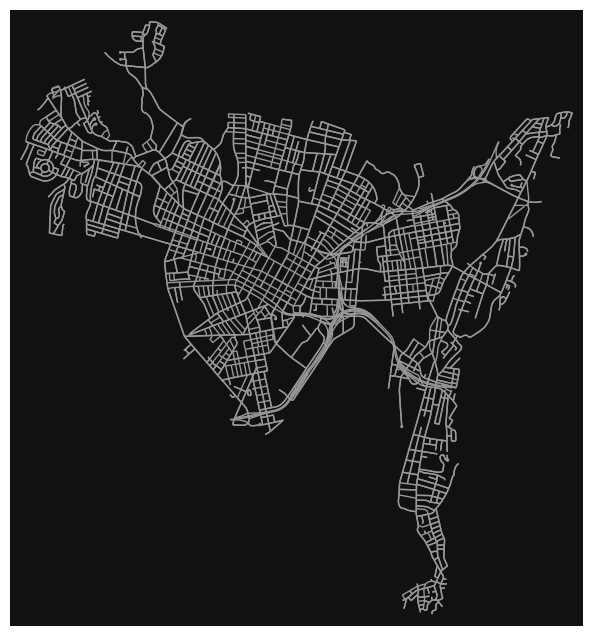

In [2]:
# Get the city's street network and plot it
street_graph = ox.graph_from_place(city, network_type="drive")
ox.plot_graph(street_graph, node_size=0)
plt.show()

In [3]:
# Convert the road network to a GeoDataFrame
nhv_streets = ox.graph_to_gdfs(street_graph)[1].to_crs(epsg=3857).reset_index()
nhv_streets.head()

,u,v,key,osmid,highway,maxspeed,name,oneway,reversed,length,geometry,ref,lanes,bridge,tunnel,access,width,junction
0,178504723,178622919,0,658267229,residential,25 mph,Front Street,False,False,100.278640,"LINESTRING (-8114233.398 5057507.827, -8114231...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,178504723,178544908,0,658267229,residential,25 mph,Front Street,False,True,155.875944,"LINESTRING (-8114233.398 5057507.827, -8114235...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,178504725,178504723,0,17201230,residential,NaN,Chambers Street,True,False,79.258751,"LINESTRING (-8114330.535 5057548.52, -8114322....",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,178504725,178622920,0,17229464,residential,NaN,East Pearl Street,True,False,101.895325,"LINESTRING (-8114330.535 5057548.52, -8114328....",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,178504725,178504728,0,37346367,residential,NaN,Chambers Street,False,False,105.783512,"LINESTRING (-8114330.535 5057548.52, -8114339....",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Look at the options for type of roadway
# Explode because some of the roads have a list of multiple
nhv_streets["highway"].explode().unique()

<StringArray>
[   'residential',      'secondary',  'motorway_link',        'primary',
       'tertiary',       'motorway',   'primary_link',          'trunk',
 'secondary_link',  'tertiary_link']
Length: 10, dtype: str

### Generate Target Area

In [5]:
nhv = h.create_target_area(city, 1500)
targetGDF = nhv["targetGDF"]

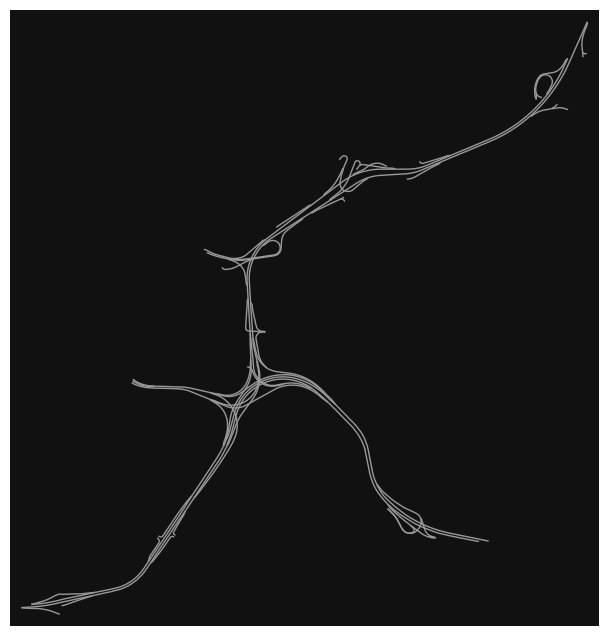

In [6]:
# Plot the highway network
ox.plot_graph(nhv['highway_graph'], node_size=0)
plt.show()

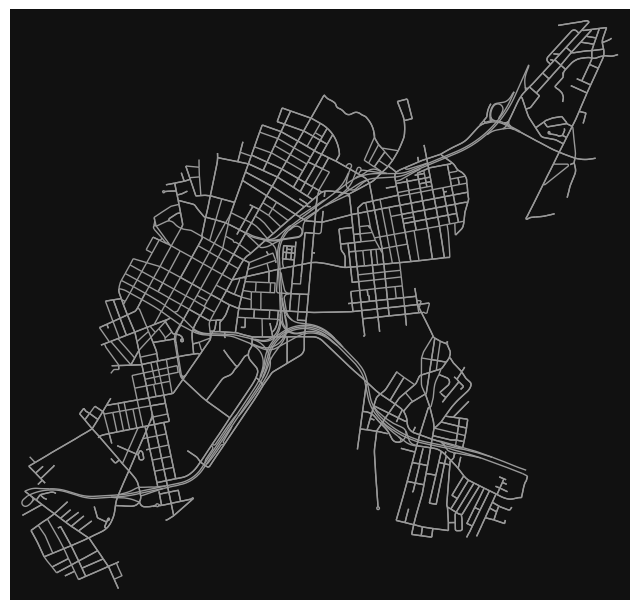

In [7]:
# Plot the street network in the target area
ox.plot_graph(nhv["target_graph"], node_size=0)
plt.show()

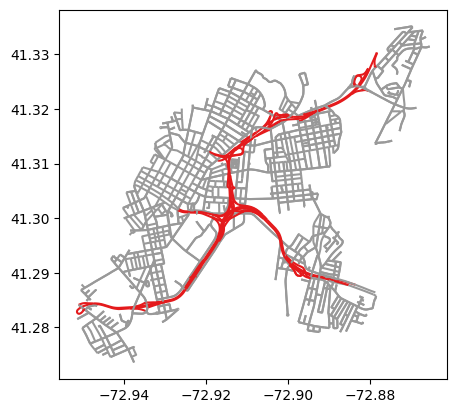

In [8]:
# Highlight the highway network
targetGDF.plot(column="is_highway", cmap="Set1_r")
plt.show()

In [9]:
ox.basic_stats(nhv["target_graph"])

{'n': 1071,
 'm': 2646,
 'k_avg': 4.9411764705882355,
 'edge_length_total': 393164.9388063162,
 'edge_length_avg': 148.58841224728502,
 'streets_per_node_avg': 3.123249299719888,
 'streets_per_node_counts': {0: 0, 1: 89, 2: 13, 3: 653, 4: 309, 5: 7},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.08309990662931839,
  2: 0.012138188608776844,
  3: 0.6097105508870215,
  4: 0.28851540616246496,
  5: 0.006535947712418301},
 'intersection_count': 982,
 'street_length_total': 251830.031497838,
 'street_segment_count': 1617,
 'street_length_avg': 155.73904236106247,
 'circuity_avg': 1.0394158153862536,
 'self_loop_proportion': 0.0030921459492888066}

### Generate Points

In [10]:
# Generate points along street network
points = h.street2Point(targetGDF[~targetGDF["is_highway"]], 1000)
print(len(points))
points.head()

/Users/michaelwillen/Documents/Yale/School/2025-26/Senior Project/helpers.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  totalLength = roadDDF.geometry.length.iloc[0]
/Users/michaelwillen/Documents/Yale/School/2025-26/Senior Project/helpers.py:40: UserWarning: Geometry is in a geographic CRS. Results from 'interpolate' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pointList.append(roadDDF.geometry.interpolate(dist))


236


,id,lon,lat
0,0,-72.89486,41.30615
1,1,-72.92340,41.30142
2,2,-72.91281,41.30487
3,3,-72.88687,41.28796
4,4,-72.90154,41.29135


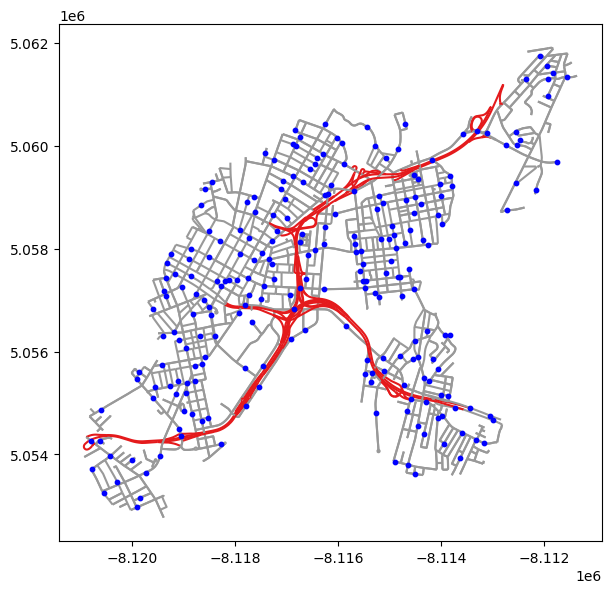

In [11]:
# Convert to GeoDataFrame
pointsGDF = gpd.GeoDataFrame(points, geometry=gpd.points_from_xy(points.lon, points.lat, crs="EPSG:4326"))

# Plot the generated points
fig, ax = plt.subplots(figsize=(7,7))
targetGDF.to_crs(3857).plot(ax=ax, column="is_highway", cmap="Set1_r", zorder=0)
pointsGDF.to_crs(3857).plot(ax=ax, color="blue", markersize=10)
plt.show()

### HowLoud API

In [12]:
filename = '_data/howloud_nhv.json'

# [ONLY RUN WHEN NEEDED]
# scores_from_json(pointsGDF, hl_api_key, filename)

# Load HowLoud data from file backup instead
scoresGDF = h.load_scores(filename)

# Get distance to highway for each point
scoresGDF["distance"] = h.network_distance(scoresGDF, nhv["highwayGDF"])

scoresGDF.head()

,id,lat,lon,status,airports,airportstext,local,localtext,score,scoretext,traffic,traffictext,geometry,distance
0,0,41.30615,-72.89486,OK,0,Calm,4,Busy,67,Busy,39,Busy,POINT (-72.89486 41.30615),1492.284980
1,1,41.30142,-72.92340,OK,0,Calm,2,Active,59,Busy,53,Busy,POINT (-72.9234 41.30142),37.707935
2,2,41.30487,-72.91281,OK,0,Calm,1,Active,63,Busy,46,Busy,POINT (-72.91281 41.30487),95.530436
3,3,41.28796,-72.88687,OK,4,Busy,1,Active,58,Busy,49,Busy,POINT (-72.88687 41.28796),258.544220
4,4,41.29135,-72.90154,OK,0,Calm,1,Active,69,Active,41,Busy,POINT (-72.90154 41.29135),192.642418


## Analysis

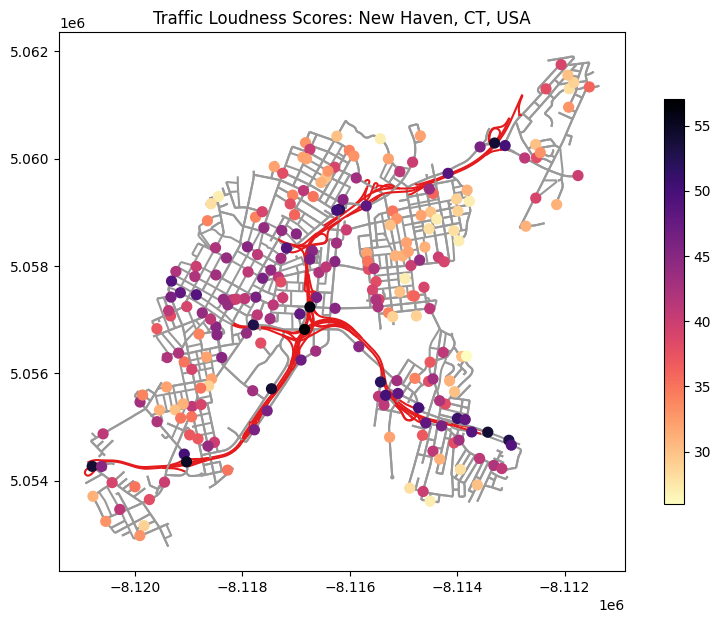

In [13]:
# Map the traffic scores
h.map_data(targetGDF, scoresGDF, "traffic", "Traffic Loudness Scores: " + city)

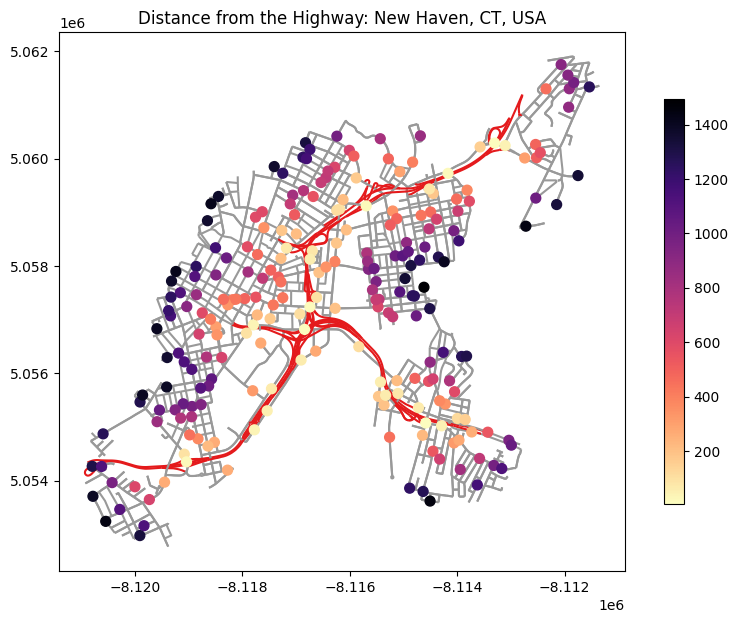

In [14]:
# Map distance from highway
h.map_data(targetGDF, scoresGDF, "distance", "Distance from the Highway: " + city)

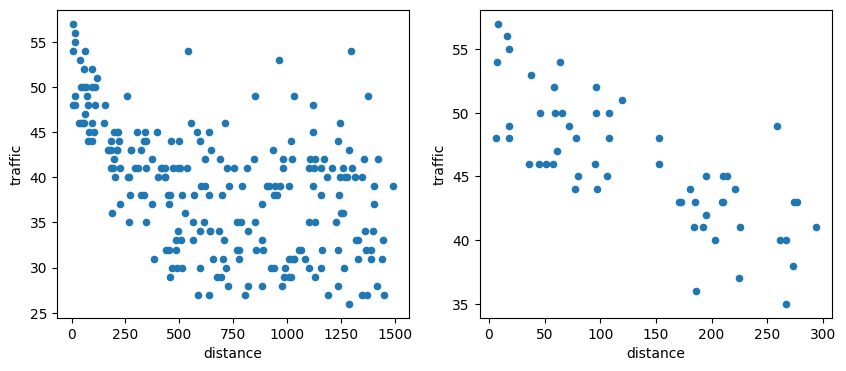

In [15]:
fig,ax = plt.subplots(1,2, figsize=(10,4))
scoresGDF.plot(ax=ax[0], kind="scatter", x="distance", y="traffic")
scoresGDF[scoresGDF["distance"]<300].plot(ax=ax[1], kind="scatter", x="distance", y="traffic")
plt.show()

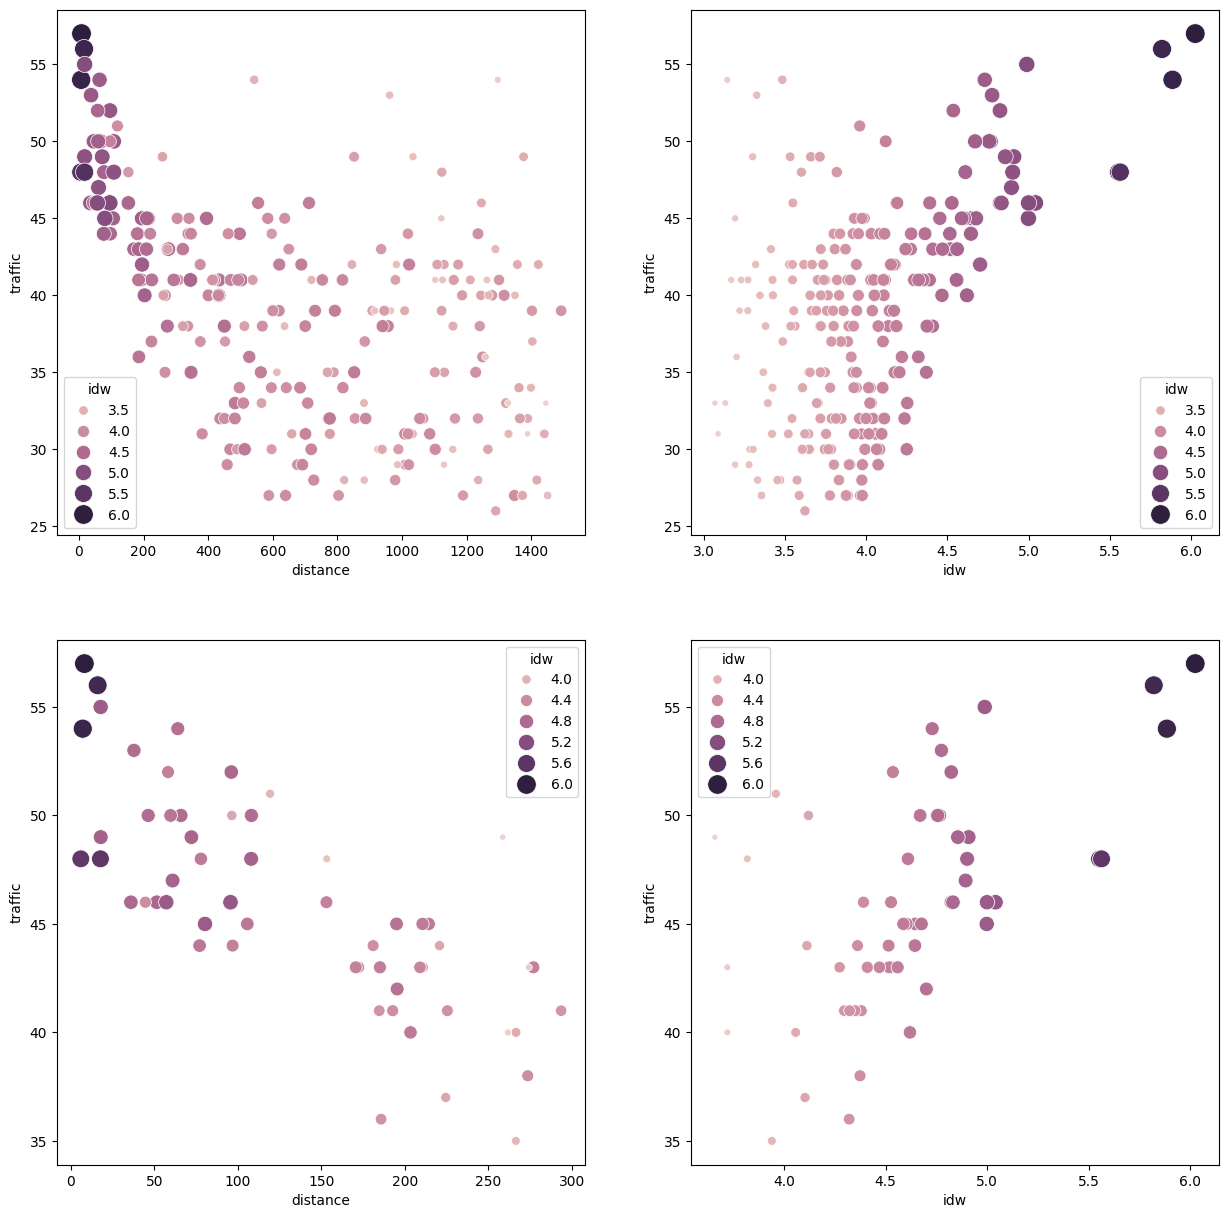

In [16]:
scoresGDF["idw"] = scoresGDF.to_crs(3857).geometry.apply(lambda x: math.log((1000 / nhv["highwayGDF"].distance(x)).sum()))

fig, ax = plt.subplots(2,2,figsize=(15,15))
sns.scatterplot(scoresGDF, x='distance', y='traffic', size='idw', sizes=(20, 200), hue="idw", ax=ax[0][0])
sns.scatterplot(scoresGDF[scoresGDF["distance"]<300], x='distance', y='traffic', size='idw', sizes=(20, 200), hue="idw", ax=ax[1][0])

sns.scatterplot(scoresGDF, x='idw', y='traffic', size='idw', sizes=(20, 200), hue="idw", ax=ax[0][1])
sns.scatterplot(scoresGDF[scoresGDF["distance"]<300], x='idw', y='traffic', size='idw', sizes=(20, 200), hue="idw", ax=ax[1][1])
plt.show()

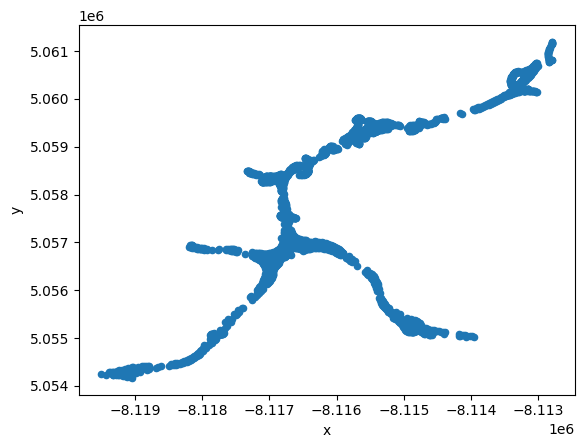

In [17]:
cds = nhv["highwayGDF"].get_coordinates().drop_duplicates()
cds.plot(x="x",y="y", kind = "scatter")
plt.show()

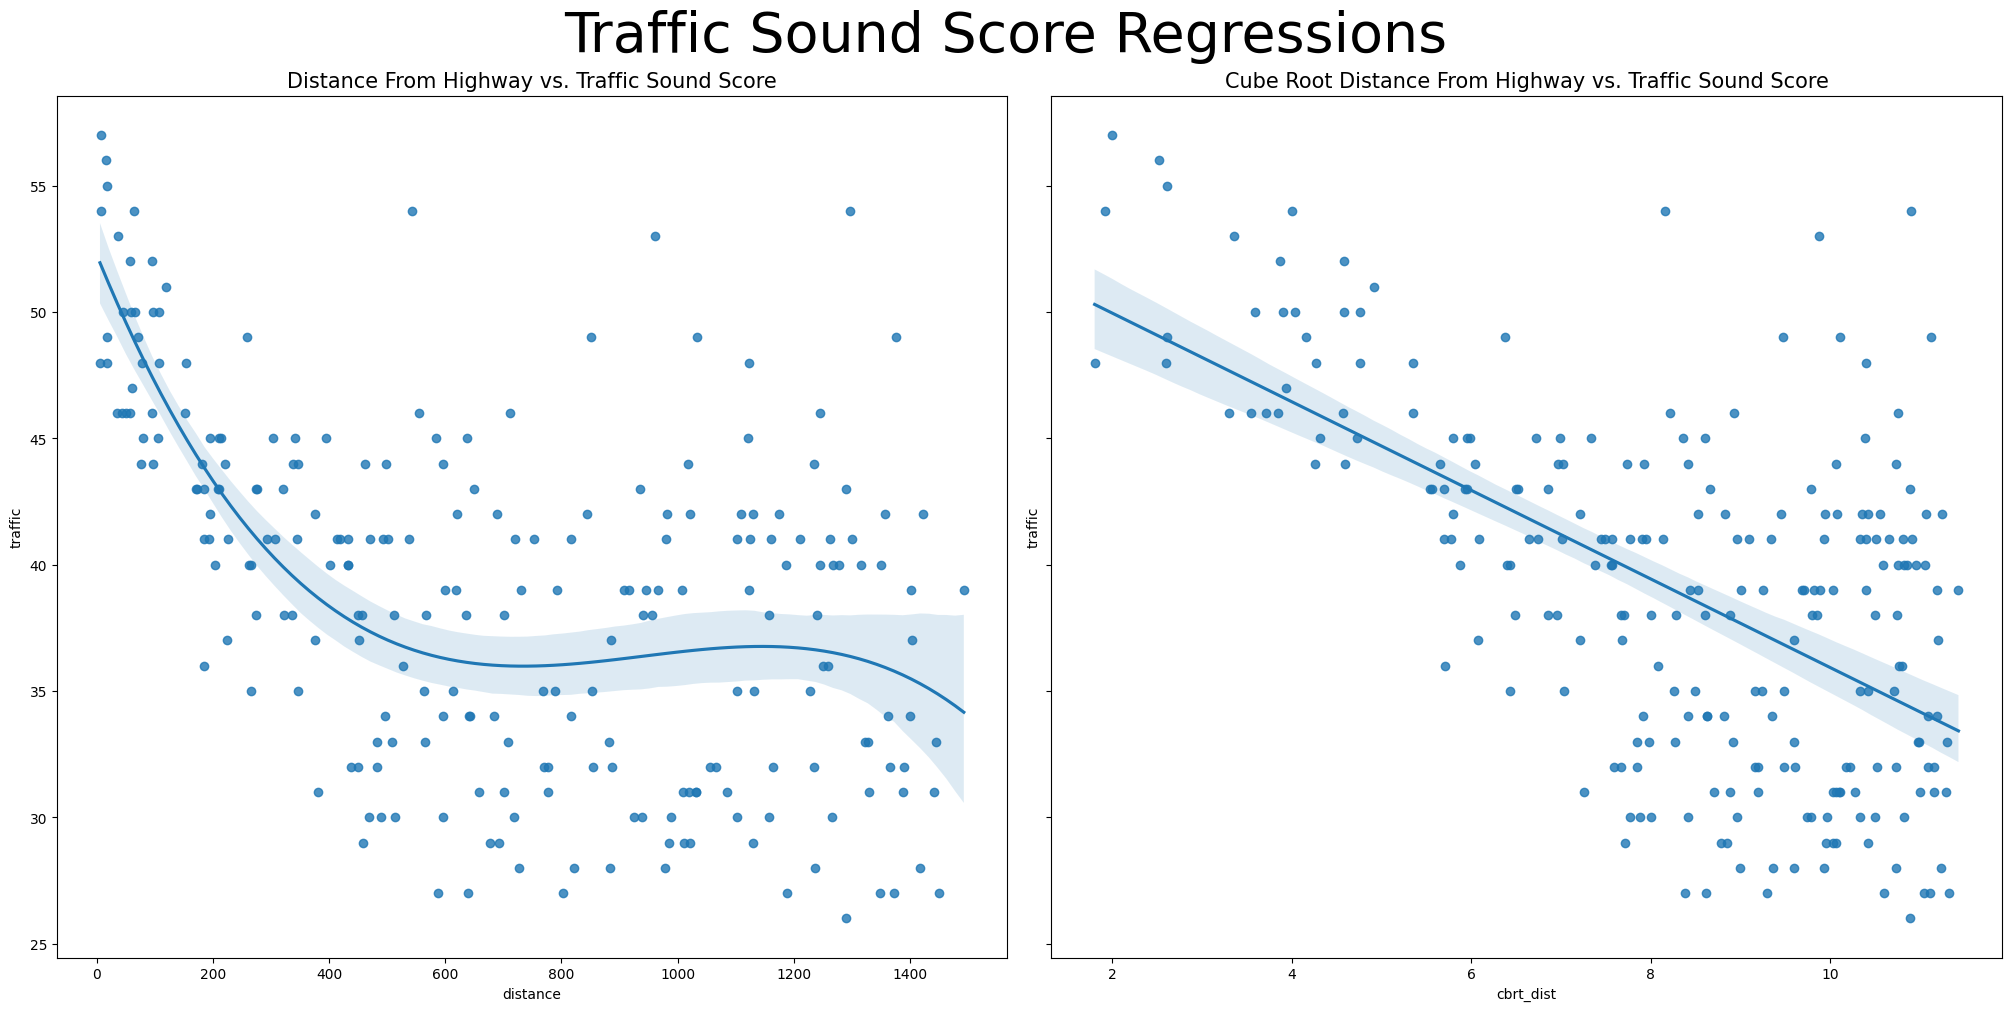

In [18]:
# scoresGDF = scoresGDF[scoresGDF["distance"] < 300]
scoresGDF["sqrt_dist"] = scoresGDF["distance"].apply(math.sqrt)
scoresGDF["cbrt_dist"] = scoresGDF["distance"].apply(math.cbrt)

# Create regular and polynomial regression plots for distance vs. traffic
fig, ax = plt.subplots(1, 2, figsize=(20,10), sharey=True, layout='constrained')
sns.regplot(ax=ax[0], x="distance", y="traffic", data=scoresGDF, order=3)
# sns.regplot(ax=ax[1], x="sqrt_dist", y="traffic", data=scoresGDF)
sns.regplot(ax=ax[1], x="cbrt_dist", y="traffic", data=scoresGDF)
ax[0].set_title("Distance From Highway vs. Traffic Sound Score", fontsize=15)
ax[1].set_title("Cube Root Distance From Highway vs. Traffic Sound Score", fontsize=15)
plt.suptitle("Traffic Sound Score Regressions", fontsize=40)
plt.show()

## BASICALLY! There is variance in traffic noise at the same distance from highways. How can we explain it?

In [19]:
scoresGDF[["traffic","distance","sqrt_dist","cbrt_dist", "idw"]].corr()

,traffic,distance,sqrt_dist,cbrt_dist,idw
traffic,1.000000,-0.500104,-0.570539,-0.592077,0.492042
distance,-0.500104,1.000000,0.978229,0.955805,-0.754890
sqrt_dist,-0.570539,0.978229,1.000000,0.995812,-0.816094
cbrt_dist,-0.592077,0.955805,0.995812,1.000000,-0.834908
idw,0.492042,-0.754890,-0.816094,-0.834908,1.000000


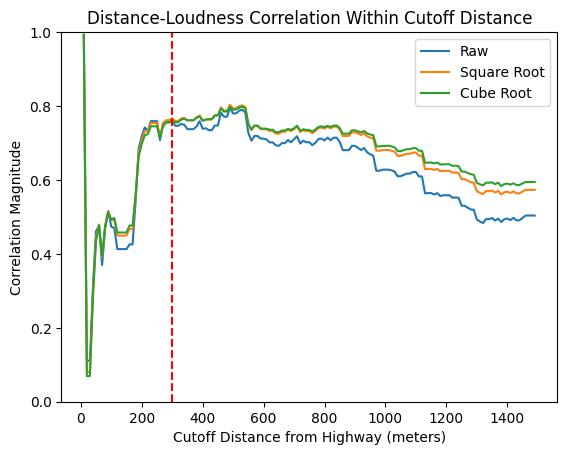

In [20]:
# Get a range of cutoff distances and calculate correlations within those distances from the highway
corrDF = pd.DataFrame(np.arange(0, scoresGDF["distance"].max(), 10), columns=["cutoff"])
corrs = corrDF["cutoff"].apply(lambda x: (scoresGDF[scoresGDF["distance"] < x])[["traffic","distance","sqrt_dist","cbrt_dist","idw"]].corr().iloc[0])
corrs = abs(corrs) # For a positive graph
corrDF = pd.concat([corrDF, corrs], axis=1)

# Plot the correlation within a given cutoff distance
fig, ax = plt.subplots()
sns.lineplot(corrDF, ax=ax, x="cutoff", y="distance", errorbar=None)
sns.lineplot(corrDF, ax=ax, x="cutoff", y="sqrt_dist", errorbar=None)
sns.lineplot(corrDF, ax=ax, x="cutoff", y="cbrt_dist", errorbar=None)
# sns.lineplot(corrDF, ax=ax, x="cutoff", y="idw", errorbar=None)
plt.axvline(x=300, color='r', linestyle='--')
plt.title("Distance-Loudness Correlation Within Cutoff Distance")
plt.ylabel("Correlation Magnitude")
plt.xlabel("Cutoff Distance from Highway (meters)")
plt.ylim(0,1)
plt.legend(['Raw', 'Square Root', 'Cube Root'])
plt.show()

In [21]:
# Get buildings in the target area
buildingsGDF = ox.features_from_polygon(nhv['buffer_polygon'], {'building':True})
vegetationGDF = ox.features_from_polygon(nhv['buffer_polygon'], {'natural':['wood', 'scrub', 'heath', 'grassland', 'fell', 'tree', 'tree_row', 'shrubbery']})


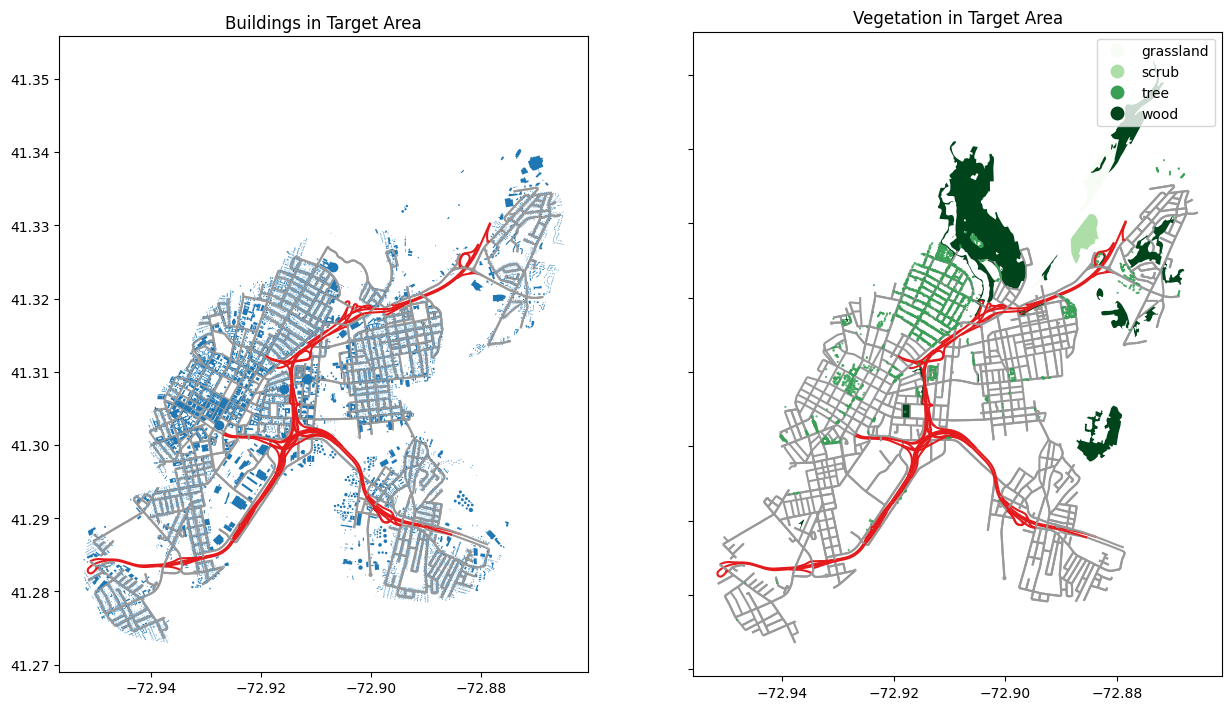

In [22]:
fig, ax = plt.subplots(1,2,figsize=(15,10), sharey=True)
buildingsGDF.plot(ax=ax[0])
targetGDF.plot(ax=ax[0], column="is_highway", cmap="Set1_r", zorder=0)
ax[0].set_title("Buildings in Target Area")

vegetationGDF.plot(ax=ax[1], column="natural", cmap="Greens", markersize=0.2, legend=True)
targetGDF.plot(ax=ax[1], column="is_highway", cmap="Set1_r", zorder=0)
ax[1].set_title("Vegetation in Target Area")
plt.show()

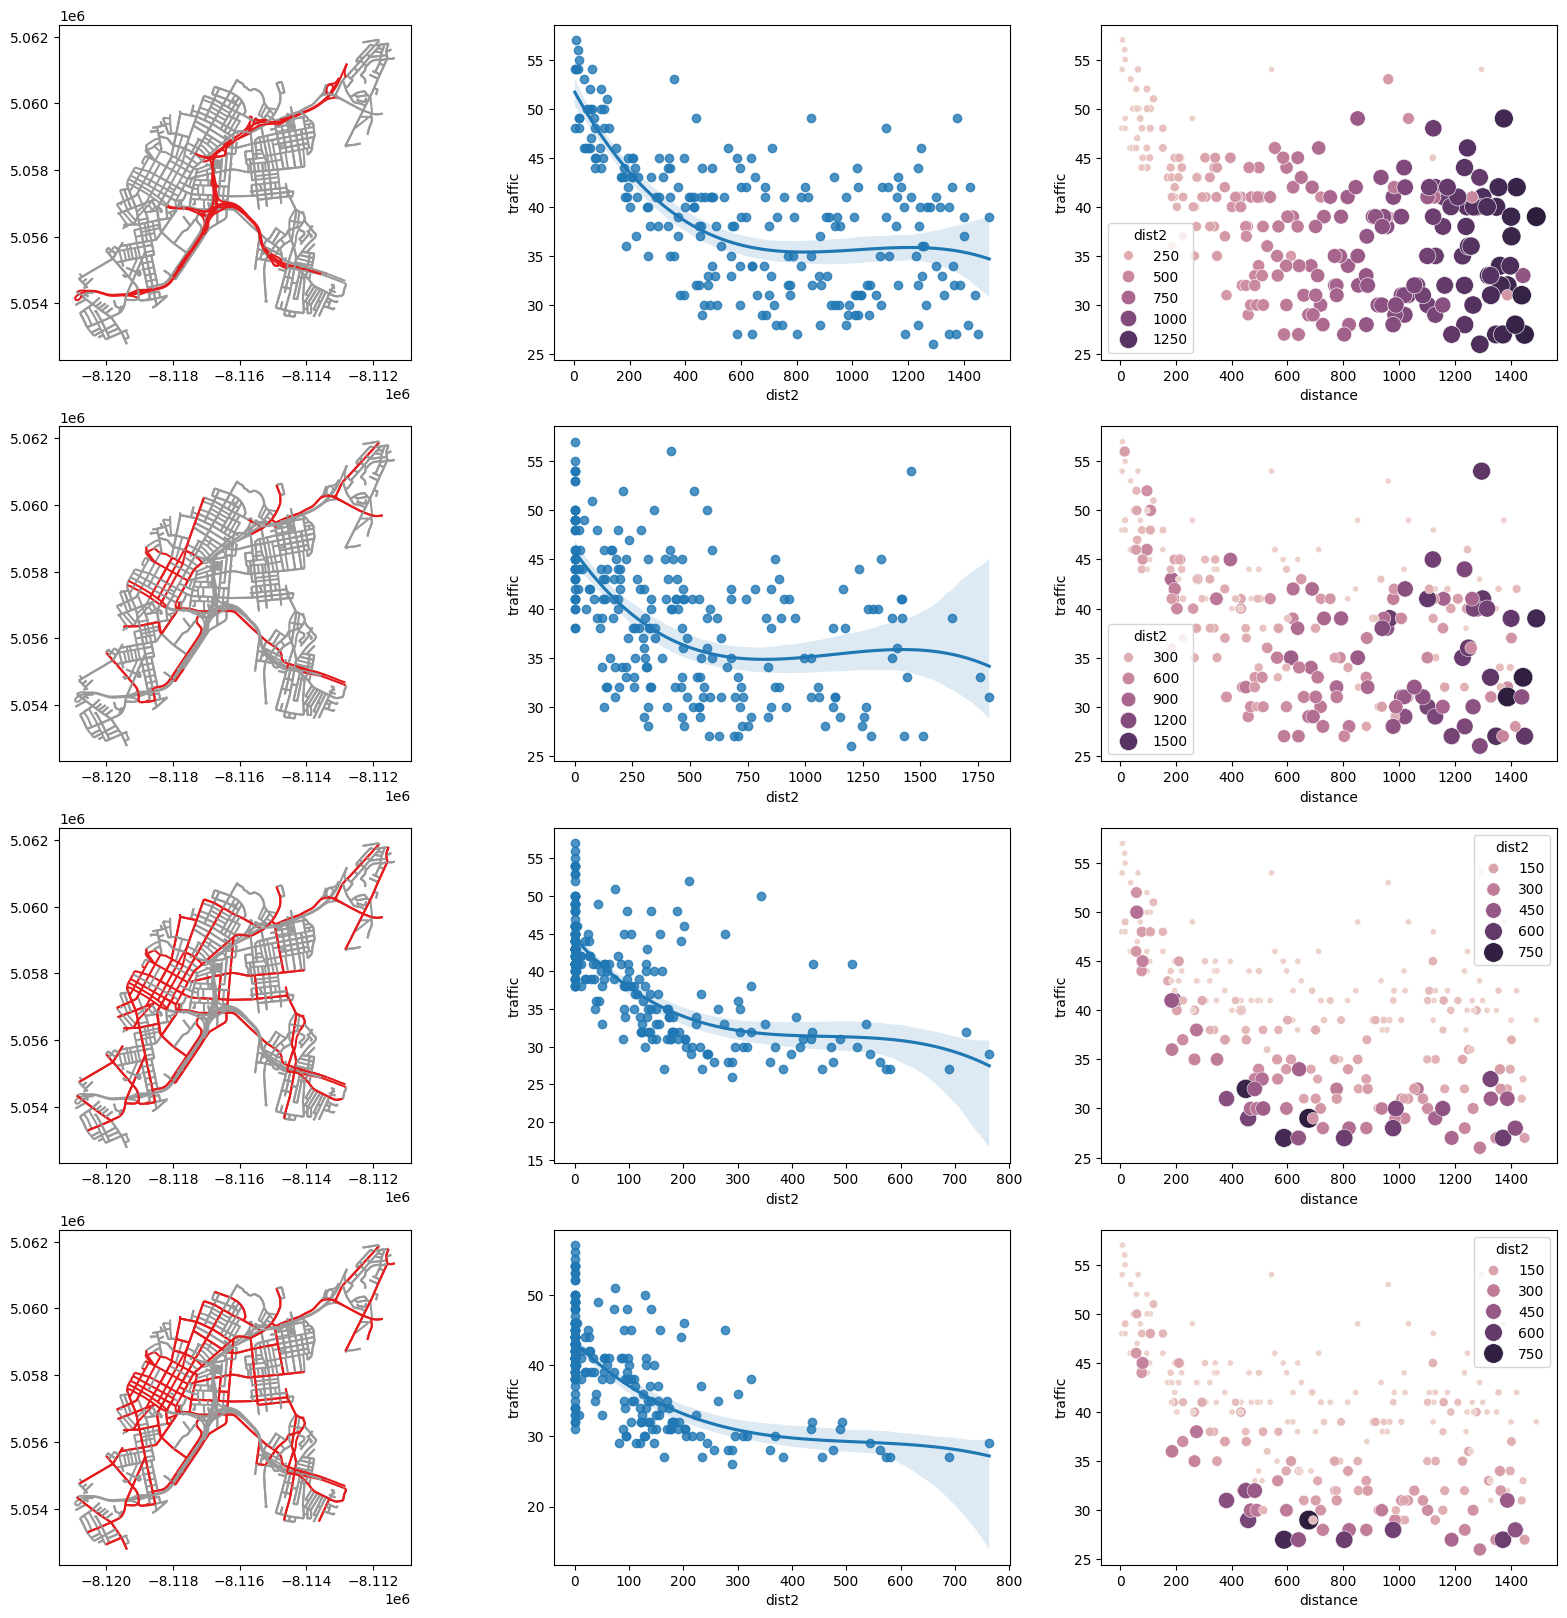

In [23]:
roadtypes = [['motorway','motorway_link'],['trunk','primary','primary_link'],
             ['secondary','secondary_link'],['tertiary','tertiary_link']]

fig, ax = plt.subplots(4, 3, figsize=(20,20))

for k in range(0,4):
    # Get the desired road types
    if k == 0:
        include = [i for sublist in roadtypes[0:k+1] for i in sublist]
    else:
        include = [i for sublist in roadtypes[1:k+1] for i in sublist]
    targetGDF["is_major"] = targetGDF["highway"].astype(str).isin(include)

    # Plot those road types
    targetGDF.to_crs(3857).plot(ax=ax[k][0], column="is_major", cmap="Set1_r")

    # Get distances to road types
    majorGDF = targetGDF[targetGDF["is_major"]].to_crs(3857)
    scoresGDF["dist2"] = scoresGDF.to_crs(3857).geometry.apply(lambda x: majorGDF.distance(x).min())

    # Plot distance vs. traffic noise score
    sns.regplot(ax=ax[k][1], x="dist2", y="traffic", data=scoresGDF, order=3)

    sns.scatterplot(scoresGDF, x='distance', y='traffic', size='dist2', ax=ax[k][2], sizes=(20, 200), hue="dist2")

plt.show()

## LiDAR Data

Typical class distribution in USGS LiDAR
| Class | Meaning | Typical % |
| :---: | --- | --- |
| 1	| Unclassified | 5–20%
| 2	| Ground | 30–50%
| 3	| Low vegetation | 5–10%
| 4	| Medium vegetation | 5–15%
| 5	| High vegetation |	10–25%
| 6 | Buildings | 1–5%
| 7 | Noise | <1%
| 9	| Water | 1–5%

In [24]:
filename = "/_data/lidar_nhv.pkl"
# cloudGDF = h.get_point_cloud(nhv["bufferGDF"], filename)

<Axes: >

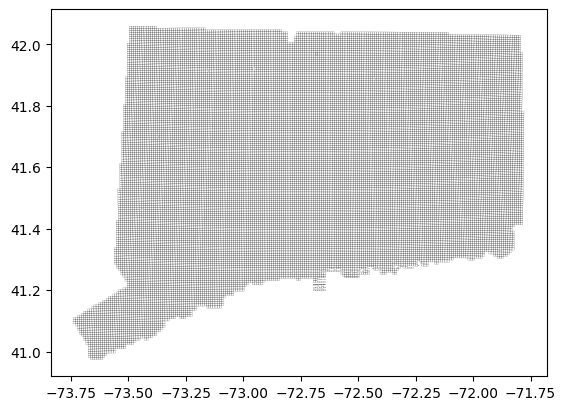

In [25]:
lidar_tiles = gpd.read_file("_data/tileindex_CT_statewide_m10296.gpkg").to_crs(4326)
lidar_tiles.plot(edgecolor='black',facecolor='none', linewidth=0.1)

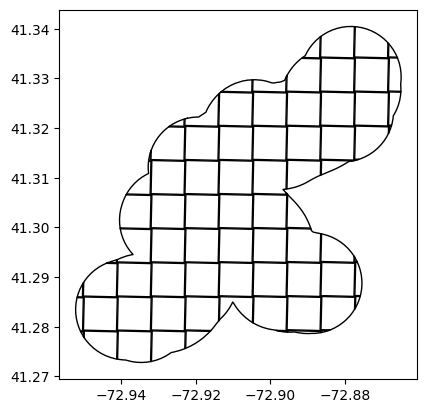

In [26]:
target_tiles = gpd.clip(lidar_tiles, nhv["bufferGDF"])
target_tiles.plot(edgecolor="black",facecolor='none')
plt.show()

In [ ]:
# Load LAZ files for target area 
ext = target_tiles[['url','filename']].values.tolist()
# h.get_lidar_tiles(ext)

100%|██████████| 78/78 [13:03<00:00, 10.05s/it]


## Crude Building Barrier Methods

Attempting this as a precursor to using LiDAR data to calculate a similar metric. Essentially, creating lines between every study point and the nearest point on the highways, then intersecting those lines with the buildings GDF to get the total proportion of the line blocked by buildings.

I'll do the same with building count and then use those two measurements to get average thickness, to see what, if any, of those matter. 

A further adjustment to this after proof of concept will be to buffer the line somewhat and then get coverage over that area, as sound does not travel in a direct line. I can then compute similar statistics over that buffer area.

A further, further adjustment will be to compute this metric to more than just the closest highway point, but to get a fuller sense of it in all directions. I'll likely have to come up with a way to put in the influence of everything nearby while not having anything far away affect it too much.

---

The goal will be to replace this all with the LiDAR data and create a model to understand which variables have the greatest impact on the sound score and how it varies at an equal distance.

When I add the LiDAR data, I'll add things like barrier type (vegetation, buildings, elevation) and the height of barriers.

There are parts of the highway in New Haven where sound barriers are clearly present. I'll go through Google Maps and take note, then create a layer (in ArcGIS?). Maybe I should take points solely outside the extent of those barriers, or factor them into my analysis.

I can also add things like the distance of a given object from the highway (i.e. trees <50 feet away probably have a stronger influence than trees several hundred feet away).

I can then use the model to try to predict how loud some other points will be, given a set of points at equal distance from the highway, to determine its effectiveness.

AttributeError: 'GeometryCollection' object has no attribute 'plot'

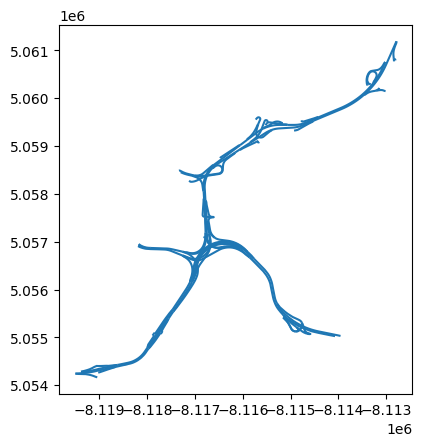

In [ ]:
highwayGDF = nhv["highwayGDF"]
highwayGDF.plot()

buildingsGDF.union_all()

def calculate_obstruction(points: gpd.GeoDataFrame, highway: gpd.GeoDataFrame, buildings: gpd.GeoDataFrame):


    return